# Polygonal Path Image: a reproducible synthetic benchmark

## Goal

Learn how a dark curve becomes a path-voting image, measure recovery against its known centerline, and explore the effect of segment length, number of segments, and tortuosity filtering.

This notebook recomputes one scene and a small parameter sweep. The larger figures read the committed benchmark results, so opening the tutorial does not rerun the full experiment. The inputs are deliberately **synthetic**: they do not reproduce the MICCAI 2012 clinical dataset.

**Observed baseline:** across the 81 noisy scenarios at the requested 2% budget, mean per-scene coverage is 93.1% for PPI and 95.9% for raw darkness; mean off-tube false-positive rates are 0.72% and 0.48%, respectively. Read these as results on isolated synthetic curves; the dataset does not establish a clinical ranking.

Software authors: Paula Agregán Reboredo, Vincent Bismuth, and Laurent Najman. See the [project documentation](https://github.com/lnajman/polygonal-path-image) and [MICCAI 2012 reference](https://doi.org/10.1007/978-3-642-33418-4_2).

## Setup

Run this notebook from a checkout of the repository, with its `benchmarks/` and `docs/benchmarks/` directories available. From the repository root:

```bash
python -m pip install polygonal-path-image==0.1.0 "matplotlib>=3.8" jupyterlab
jupyter lab examples/ppi_synthetic_benchmark.ipynb
```

This uses a published binary wheel where available. For development in the checkout, the alternative is `python -m pip install -e '.[benchmark,notebook]'`, which builds the extension locally. Choose that environment's Python kernel. The notebook uses NumPy, Matplotlib, and the compiled `polygonal_path_image` package. All image generation and measurements use explicit parameters and seeds; no external images or network connection are needed when running the cells.

In [1]:
import hashlib
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

# Both the repository root and examples/ are valid notebook working directories.
repo = next(
    (
        path
        for path in (Path.cwd(), Path.cwd().parent)
        if (path / "benchmarks" / "synthetic.py").is_file()
    ),
    None,
)
if repo is None:
    raise RuntimeError("Open this notebook from the repository root or examples/ directory.")

if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))

In [2]:
from benchmarks.plots import (
    plot_budget_curves,
    plot_case,
    plot_direction,
    plot_parameters,
    plot_robustness,
    plot_runtime,
    set_style,
)
from benchmarks.synthetic import evaluate_prediction, generate_case, select_at_budget
from polygonal_path_image import compute_ppi, filter_tortuosity, voting

set_style()
plt.rcParams["figure.dpi"] = 110
print("NumPy:", np.__version__)

NumPy: 2.4.6


## Steps

### 1. Define the scene and evaluation rule

The reference is a densely sampled circular arc (a straight line when bend is zero), with 48-pixel arclength and Gaussian cross-section of width σ=1.25 pixels. Angles are measured clockwise from the horizontal; `angle_deg` is the tangent at the arc midpoint, and `bend_deg` is the total turning angle.

A dark curve is placed on gray background 200. Gaussian intensity noise is added before rounding and clipping to `uint8`. The 128×128 image supplies context; a centered 64×64 **region of interest (ROI)** is used for scoring. The whole reference and its 2-pixel tube fit in that ROI. This margin does not eliminate boundary effects: paths originating outside the ROI can still vote inside it.

We predeclare a **2% ROI area budget** for both PPI votes and the simple raw-darkness baseline. Selection includes all scores tied at the cutoff, so the *actual* fraction may exceed 2%. Raw darkness is `max(200 − image, 0)`. Positive scores only are eligible; a constant positive score can therefore select the entire ROI. This is a ranking experiment, not a calibrated detector.

In [3]:
scene_parameters = dict(
    angle_deg=30,
    bend_deg=45,
    contrast=60,
    noise_std=15,
    seed=2012,
    size=128,
    arclength=48,
    sigma=1.25,
    background=200,
    roi_margin=32,
)
segment_length = 3
nb_segments = 10
tortuosity_threshold = 0.75
budget_fraction = 0.02
tolerance = 2.0

case = generate_case(**scene_parameters)
assert case.image.dtype == np.uint8 and case.image.shape == (128, 128)
assert case.roi.sum() == 64 * 64
print(f"Image {case.image.shape}; evaluation ROI {case.roi.sum():,} pixels")

Image (128, 128); evaluation ROI 4,096 pixels


### 2. Compute paths, filter them, and accumulate votes

`compute_ppi` minimizes the sum of sampled intensities along each candidate path; dark structures have low costs. `filter_tortuosity` keeps paths whose product of successive turn cosines reaches the threshold. A larger threshold favors straighter paths. `voting` counts visits from the retained paths; high votes are the enhancement score.

`segment_length` sets the raster step's Chebyshev length. Multiplying it by `nb_segments` describes the raster path length; it is **not** an equal-Euclidean-length curve model. This tutorial uses the released four-cone implementation. See the [validation report](../docs/validation.md) for differences from the paper.

In [4]:
started = time.perf_counter()
costs, paths = compute_ppi(case.image, segment_length, nb_segments)
accepted = filter_tortuosity(costs, paths, threshold=tortuosity_threshold)
votes, _ = voting(accepted, paths)
elapsed = time.perf_counter() - started

darkness = np.maximum(case.parameters["background"] - case.image.astype(float), 0.0)
ppi_mask, ppi_selection = select_at_budget(votes, case.roi, fraction=budget_fraction)
darkness_mask, darkness_selection = select_at_budget(
    darkness,
    case.roi,
    fraction=budget_fraction,
)
print(f"PPI pipeline elapsed time: {elapsed:.3f} s (this machine, one run)")
print(f"Accepted paths: {np.isfinite(accepted).sum():,} / {np.isfinite(costs).sum():,}")

PPI pipeline elapsed time: 0.345 s (this machine, one run)
Accepted paths: 579 / 16,384


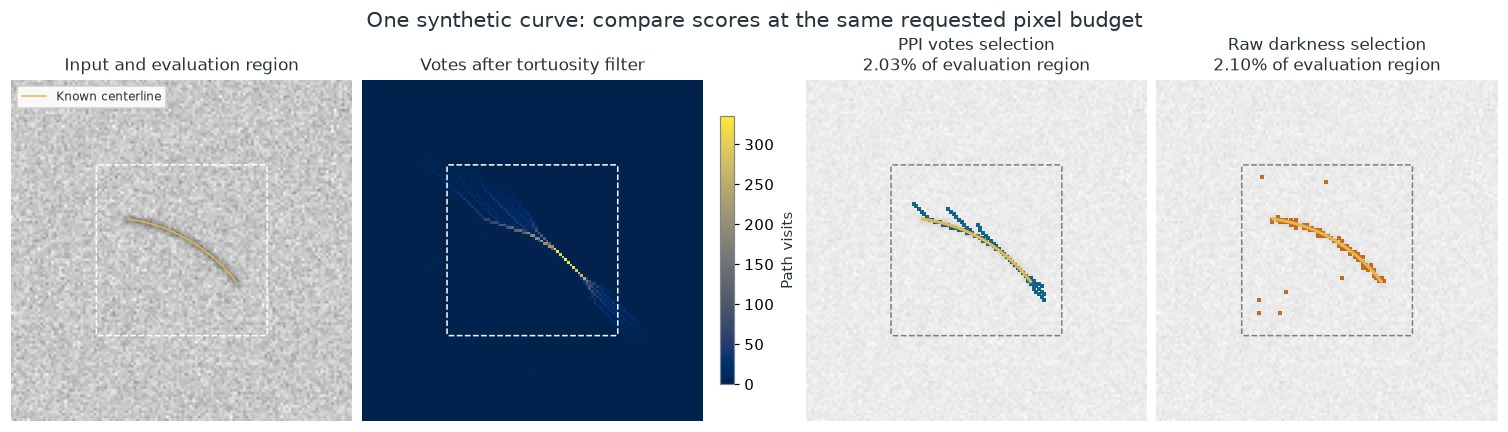

In [5]:
plot_case(case, votes, ppi_mask, darkness_mask)
plt.show()

### 3. Measure both recovery and unwanted responses

- **Centerline coverage:** arclength-weighted fraction of reference samples within 2 pixels of a selected pixel center. Higher is better.
- **Selected-pixel precision:** fraction of selected pixel centers within 2 pixels of the reference polyline. Higher is better.
- **Off-tube false-positive rate:** selected pixels outside the 2-pixel tube divided by all ROI pixels outside that tube. Lower is better.

Coverage and precision use different populations, so we report them separately rather than combining them into an F1 score. Coverage alone can reward selecting too many pixels; inspect false positives and actual selected area alongside it.

In [6]:
def measure(mask):
    return evaluate_prediction(
        mask,
        case.centerline,
        case.roi,
        tolerance=tolerance,
        distance_map=case.distance_map,
    )


def metrics_table(rows):
    columns = [
        ("centerline_coverage", "Coverage ↑"),
        ("selected_pixel_precision", "Selected-pixel precision ↑"),
        ("off_tube_false_positive_rate", "Off-tube false positives ↓"),
        ("selected_fraction", "Actual selected area"),
    ]
    lines = [
        "| Method / configuration | " + " | ".join(label for _, label in columns) + " |",
        "|:---|" + "---:|" * len(columns),
    ]
    for name, metrics in rows:
        values = ["—" if metrics[key] is None else f"{metrics[key]:.2%}" for key, _ in columns]
        lines.append("| " + name + " | " + " | ".join(values) + " |")
    display(Markdown("\n".join(lines)))


ppi_metrics = measure(ppi_mask)
darkness_metrics = measure(darkness_mask)
metrics_table([("PPI votes", ppi_metrics), ("Raw darkness", darkness_metrics)])
print(
    "Extra pixels admitted by cutoff ties:",
    {
        "PPI": ppi_selection["budget_exceeded_by_ties"],
        "darkness": darkness_selection["budget_exceeded_by_ties"],
    },
)

| Method / configuration | Coverage ↑ | Selected-pixel precision ↑ | Off-tube false positives ↓ | Actual selected area |
|:---|---:|---:|---:|---:|
| PPI votes | 100.00% | 67.47% | 0.69% | 2.03% |
| Raw darkness | 100.00% | 91.86% | 0.18% | 2.10% |

Extra pixels admitted by cutoff ties: {'PPI': 1, 'darkness': 4}


### 4. Change one setting at a time

The next cell keeps the same image, seed, tolerance, and area budget. It compares the baseline with a shorter segment, fewer segments, and a stricter tortuosity threshold. These are illustrative settings, **not** an optimized recommendation. Change the values and rerun to explore a different scene.

Shorter paths may react to small structures but also to noise. Longer paths aggregate more samples and impose a larger geometric reach. Strong tortuosity filtering can suppress irregular paths and also remove useful paths on curved structures. The outcome must be checked on the image and both error measures.

In [7]:
configurations = [
    ("Baseline: L=3, K=10, τ=.75", 3, 10, 0.75),
    ("Shorter segments: L=2, K=10, τ=.75", 2, 10, 0.75),
    ("Fewer segments: L=3, K=6, τ=.75", 3, 6, 0.75),
    ("Stricter filter: L=3, K=10, τ=.95", 3, 10, 0.95),
]
local_results = []
path_cache = {(segment_length, nb_segments): (costs, paths)}
for label, length, count, threshold in configurations:
    if (length, count) not in path_cache:
        path_cache[length, count] = compute_ppi(case.image, length, count)
    local_costs, local_paths = path_cache[length, count]
    local_accepted = filter_tortuosity(local_costs, local_paths, threshold=threshold)
    local_votes, _ = voting(local_accepted, local_paths)
    local_mask, _ = select_at_budget(local_votes, case.roi, fraction=budget_fraction)
    local_results.append((label, measure(local_mask)))
metrics_table(local_results)

| Method / configuration | Coverage ↑ | Selected-pixel precision ↑ | Off-tube false positives ↓ | Actual selected area |
|:---|---:|---:|---:|---:|
| Baseline: L=3, K=10, τ=.75 | 100.00% | 67.47% | 0.69% | 2.03% |
| Shorter segments: L=2, K=10, τ=.75 | 93.23% | 52.33% | 1.05% | 2.10% |
| Fewer segments: L=3, K=6, τ=.75 | 100.00% | 69.05% | 0.67% | 2.05% |
| Stricter filter: L=3, K=10, τ=.95 | 68.49% | 38.20% | 1.41% | 2.17% |

### 5. Read the full, saved benchmark

The committed JSON contains the complete protocol, environment, source hashes, and per-case measurements. All charts below are computed from those rows. The default view uses the same requested 2% budget; other saved budgets are 0.5%, 1%, and 5%.

The matrix varies clean-curve direction and bend, then combines noise and contrast over three angles and three seeds. Parameter comparisons retain each of the six scenes separately. Blank/noise-only controls and reflection pairs are also retained in the JSON. See the [benchmark documentation](../docs/benchmarks/README.md) for exact scope and limitations.

In [8]:
results_path = repo / "docs" / "benchmarks" / "synthetic-v0.1.0.json"
results_bytes = results_path.read_bytes()
results = json.loads(results_bytes)
print("Saved source:", results_path.relative_to(repo))
print("SHA-256:", hashlib.sha256(results_bytes).hexdigest())
print("Measurement rows:", len(results["rows"]))
for block in sorted({row["block"] for row in results["rows"]}):
    block_rows = [row for row in results["rows"] if row["block"] == block]
    print(f"{block}: {len({row['case_id'] for row in block_rows})} cases, {len(block_rows)} rows")

Saved source: docs/benchmarks/synthetic-v0.1.0.json
SHA-256: c66f0988e27d03654d38e7fd50d1c75fe0664c75daa2777825dcc92bb2b3e398
Measurement rows: 1328
controls: 10 cases, 80 rows
direction: 36 cases, 288 rows
parameters: 6 cases, 264 rows
reflection: 6 cases, 48 rows
robustness: 81 cases, 648 rows


#### The area-budget tradeoff on the tutorial scene

These are the four predeclared budgets on the same scene just computed above. The horizontal coordinate uses **actual selected ROI area**, including cutoff ties; point labels show the requested budget. Coverage and false positives have separate panels. This is one scene's ranking tradeoff, not an accuracy estimate over the full matrix or a calibrated threshold recommendation.

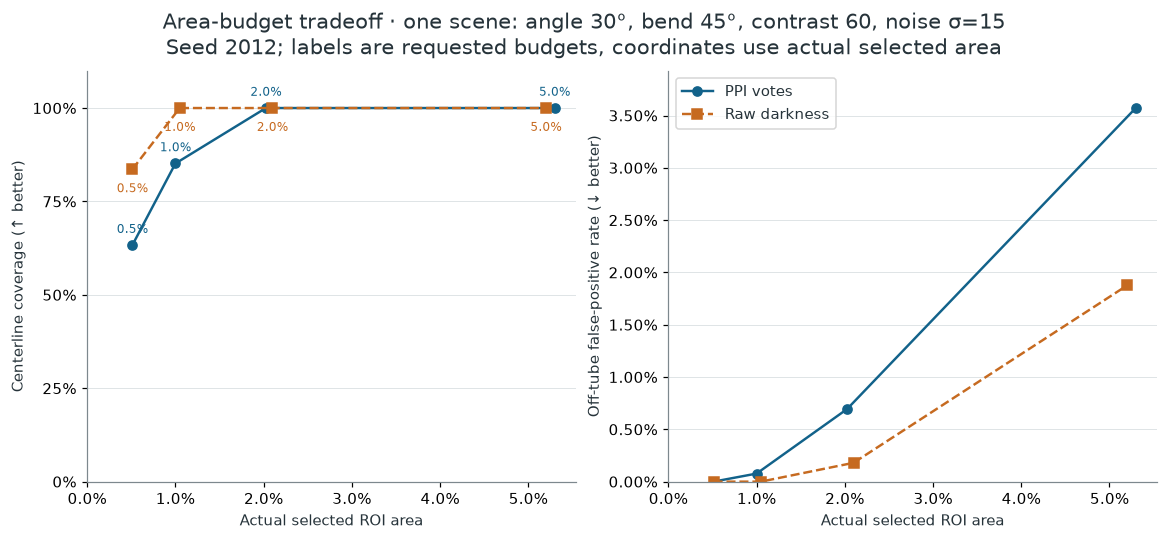

In [9]:
plot_budget_curves(results)
plt.show()

#### Direction and curvature

Compare the two methods at each clean scene. Top: how much reference length is recovered. Bottom: unwanted responses outside the reference tube. The axes are shared within each row, so bend panels can be compared directly. A directional pattern may reflect rasterization, the four candidate cones, filtering, or ties; this experiment by itself does not isolate those causes.

For the clean 45° straight line, cutoff ties make PPI select **4.25%** of the ROI at the requested 2% budget. The actual areas differ across scenes and methods. These results therefore do not establish intrinsic angular invariance or performance at exactly equal selected areas.

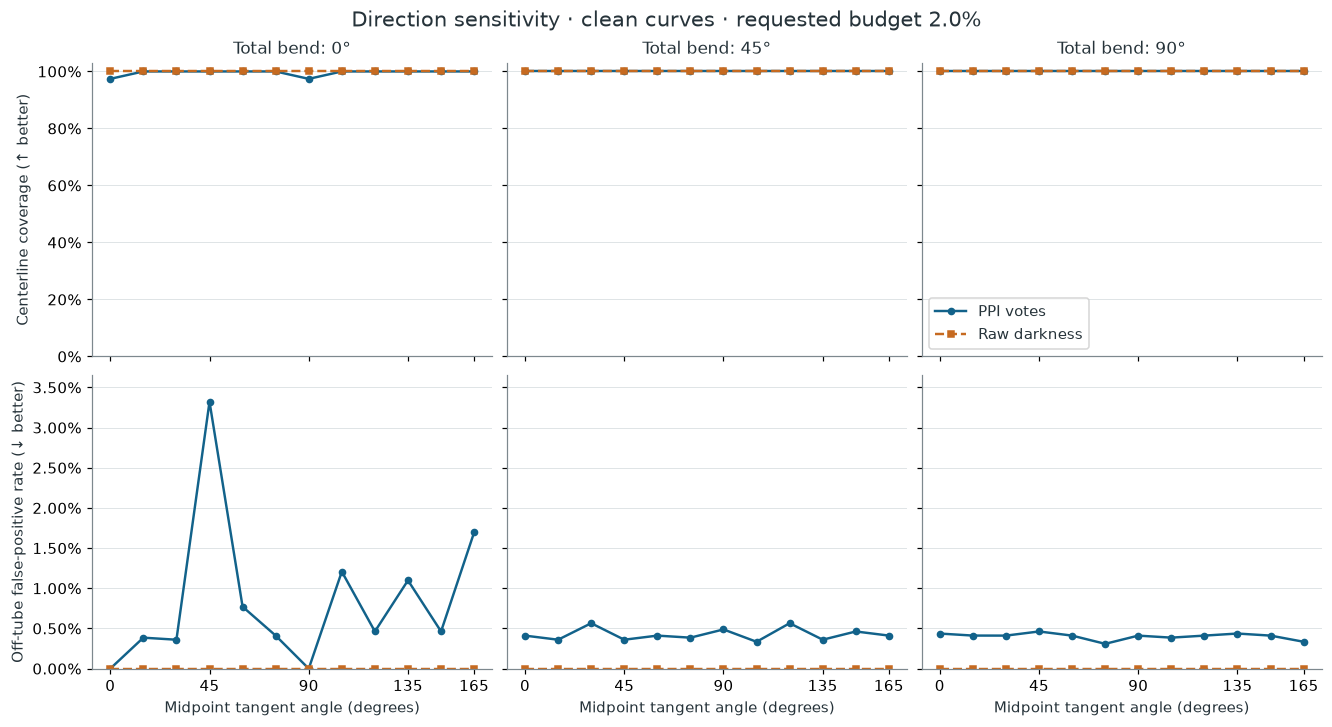

In [10]:
plot_direction(results, budget_fraction=budget_fraction)
plt.show()

#### Noise and contrast

Each plotted point averages the nine observed scenes at that noise/contrast combination: three midpoint angles × three seeds, all with a 45° total bend. Shaded bands show their minimum–maximum range, **not** a confidence interval. The raw-darkness baseline uses the same images and selection rule.

At contrast 30 and noise σ=30, the nine-scene mean coverage is **62.8% for PPI versus 70.0% for raw darkness**, while mean off-tube false-positive rates are **1.37% versus 1.81%**. Fewer unwanted selections occur together with more missed curve; the lower false-positive rate alone does not show better recovery.

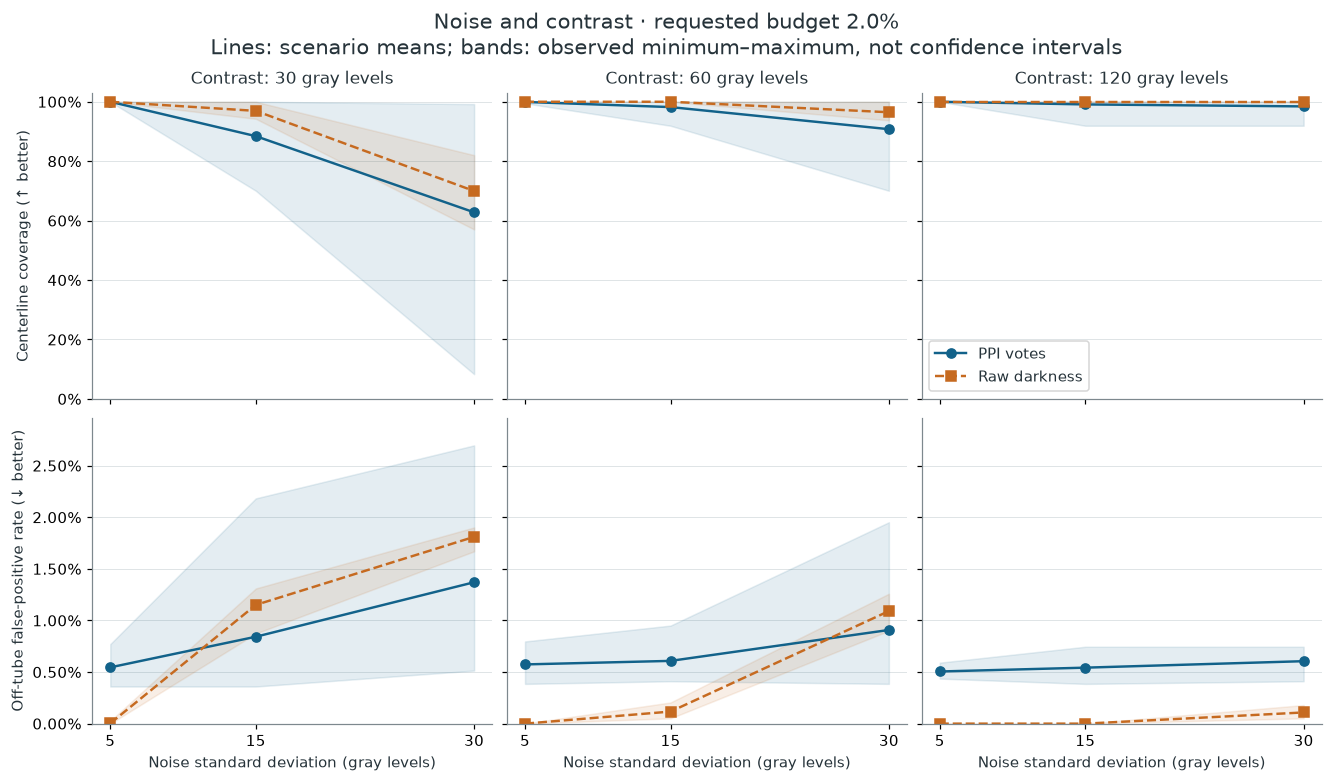

In [11]:
plot_robustness(results, budget_fraction=budget_fraction)
plt.show()

#### What happens without a target?

The controls contain only the background and optional noise; the reference is empty. Coverage and reference-dependent distances are undefined and stored as null. Every selected pixel is a false positive, so the off-tube false-positive rate equals the actual selected fraction. The table summarizes the observed selected-area range at the requested 2% budget. A ranking rule is not a test that a structure exists.

In [12]:
control_rows = [
    row
    for row in results["rows"]
    if row["block"] == "controls" and np.isclose(row["budget_fraction"], budget_fraction)
]
lines = ["| Noise σ (gray levels) | Method | Selected ROI area: mean (range) |", "|---:|:---|---:|"]
for noise in sorted({row["noise_std"] for row in control_rows}):
    for method, label in (("ppi", "PPI votes"), ("darkness", "Raw darkness")):
        selected = [
            row for row in control_rows if row["noise_std"] == noise and row["method"] == method
        ]
        assert all(row["centerline_coverage"] is None for row in selected)
        fractions = [row["selected_fraction"] for row in selected]
        lines.append(
            f"| {noise:g} | {label} | {np.mean(fractions):.2%} "
            f"({min(fractions):.2%}–{max(fractions):.2%}) |"
        )
display(Markdown("\n".join(lines)))

| Noise σ (gray levels) | Method | Selected ROI area: mean (range) |
|---:|:---|---:|
| 0 | PPI votes | 3.12% (3.12%–3.12%) |
| 0 | Raw darkness | 0.00% (0.00%–0.00%) |
| 5 | PPI votes | 1.43% (0.20%–3.03%) |
| 5 | Raw darkness | 2.60% (2.17%–3.17%) |
| 15 | PPI votes | 1.96% (0.59%–3.10%) |
| 15 | Raw darkness | 2.20% (2.17%–2.22%) |
| 30 | PPI votes | 1.74% (0.63%–3.15%) |
| 30 | Raw darkness | 2.13% (2.08%–2.22%) |

#### Parameters

Each cell represents one scene and one setting; no angle or bend is averaged away. Read coverage and false positives together. Separate color scales are intentional because coverage and off-tube error rates have different ranges. These six scenes are a sensitivity check, not a held-out tuning or generalization study.

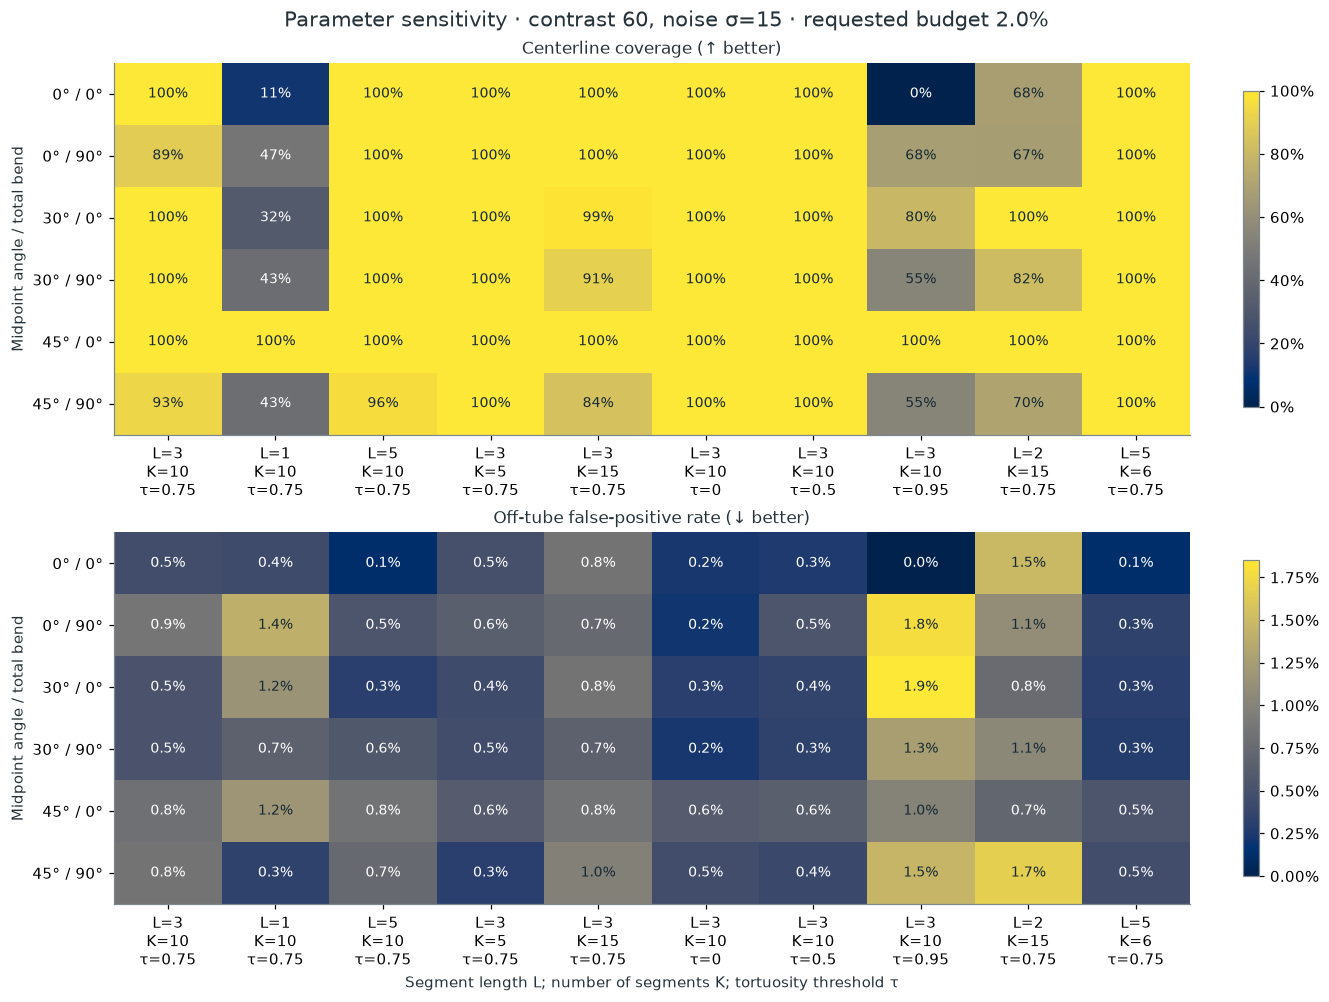

In [13]:
plot_parameters(results, budget_fraction=budget_fraction)
plt.show()

#### Runtime

Elapsed times are measurements on the machine recorded in the JSON. Each scene/configuration appears once in the timing summary, even though four area budgets were evaluated. Core timings are reused across threshold-only settings on the same image. The chart averages the three measured pipeline stages; it excludes generation, selection, evaluation, and plotting. It is not a portable performance guarantee or a formal repeated timing benchmark.

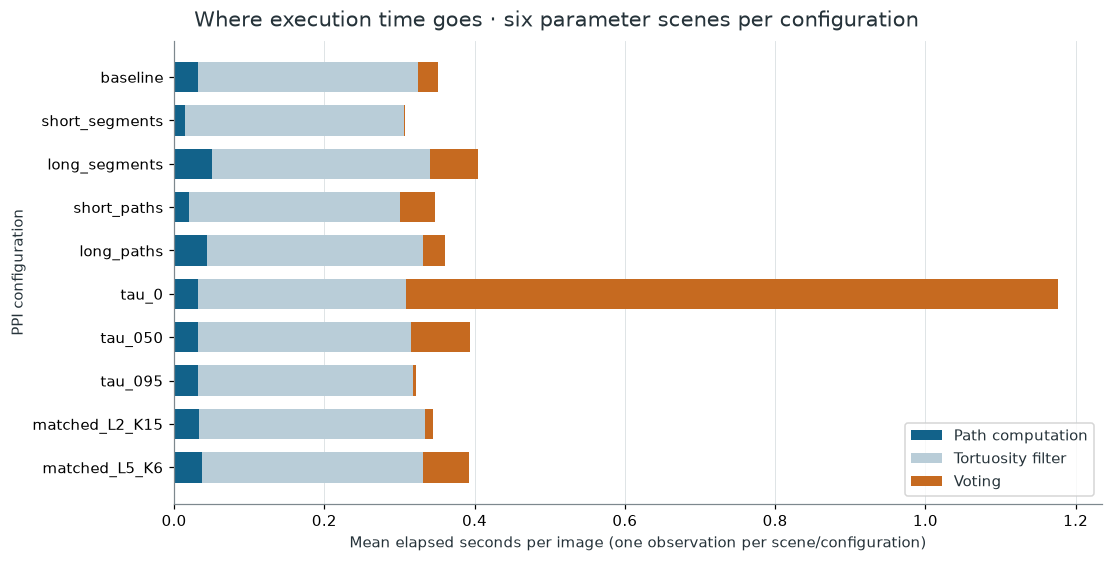

In [14]:
plot_runtime(results, budget_fraction=budget_fraction)
plt.show()

## Checks

The scene geometry and selection are inspectable. This final cell verifies that detections stay in the ROI, coverage and error rates stay in [0, 1], and the saved comparison contains both methods for the selected budget. The full test suite separately checks the geometry and measurement functions against small known answers.

In [15]:
assert not (ppi_mask & ~case.roi).any()
assert not (darkness_mask & ~case.roi).any()
for measurements in (ppi_metrics, darkness_metrics):
    for key in (
        "centerline_coverage",
        "selected_pixel_precision",
        "off_tube_false_positive_rate",
        "selected_fraction",
    ):
        value = measurements[key]
        assert value is None or 0 <= value <= 1, (key, value)
for block in ("direction", "robustness"):
    selected_rows = [
        row
        for row in results["rows"]
        if row["block"] == block and np.isclose(row["budget_fraction"], budget_fraction)
    ]
    assert {row["method"] for row in selected_rows} == {"ppi", "darkness"}
print("Tutorial checks passed.")

Tutorial checks passed.


## Next steps

Use this benchmark as a fixed baseline before modifying the algorithm. Compare one proposed change at a time on the same generated images, retain the paired per-case measurements, and inspect coverage, false positives, ties, and directional asymmetry together. Use new scenes for independent assessment before recommending settings.

This experiment contains one isolated curve per target image and independent Gaussian noise. It omits crossings, multiple structures, anatomical clutter, motion, acquisition physics, and clinical annotations. Area-budget selection always seeks high scores and is not calibrated to recognize the absence of a target. Neither high synthetic coverage nor successful execution establishes clinical segmentation accuracy.